# Evaluate and plot the results
---

In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy
import xarray as xr

import matplotlib.colorbar as colorbar
from dantro.plot.utils import ColorManager
import matplotlib.patches as patches

import plot_utils as putils
from style import colors
from data import world

In [2]:
# Default figure height and width for easy integration into Latex documents
page_width = 6.8246

# Axes titles settings
axes_title_props = dict(fontweight='bold', ha='left')

# Default ColorManager: green-yellow-red
cm_GrYeOr = ColorManager(
    cmap={'continuous': True, 'from_values': {0: colors['c_lightgreen'], 0.5: colors['c_yellow'], 1: colors['c_orange']}},
    vmin=0,
    vmax=1,
)
cm_GrYeRe = ColorManager(
    cmap={'continuous': True, 'from_values': {0: colors['c_lightgreen'], 0.5: colors['c_yellow'], 1: colors['c_red']}},
    vmin=0,
    vmax=1,
)

In [3]:
# Image directory
img_dir = "Images"

# Load the data

In [4]:
dsets = {}
for comm in sorted(os.listdir("data")):
    if not os.path.isdir(f"data/{comm}"):
        continue
    if not "trained_models" in os.listdir(f"data/{comm}"):
        continue

    dsets[comm] = dict(

        # FAO data
        FAO_data=xr.load_dataarray(f"data/{comm}/FAO_data_pooled.nc").sel({"Element": "Quantity, t"}, drop=True).transpose('Reporter', 'Year', 'Source', 'Destination').where(xr.load_dataarray(f"data/{comm}/FAO_data_mask.nc"), np.nan),

        # OT predictions
        Predictions=xr.load_dataset(f"data/{comm}/samples_stats.nc"),

        # Load two different gravity model predictions
        # Gravity (covariate-based)
        Gravity_covariates=pd.read_csv(f"data/{comm}/gravity_estimates/covariates.csv")[["FAO_data", "Destination", "Source", "Year", "predicted"]].set_index(["Destination", "Source", "Year"]).to_xarray(),

        # Gravity (fixed-effects, overparametrised)
        Gravity_fixed_effects=pd.read_csv(f"data/{comm}/gravity_estimates/fixed_effects.csv")[["FAO_data", "Destination", "Source", "Year", "predicted"]].set_index(["Destination", "Source", "Year"]).to_xarray()

    )

# Load the yield dataset
yields = xr.load_dataarray("data/FAO_data/yields.nc")
yields = yields.assign_coords({"Area": [putils.get_iso3(c) for c in yields.coords["Area"].data]})

# War in Ukraine
## Ukrainian and Russian export maps, 2021–2022

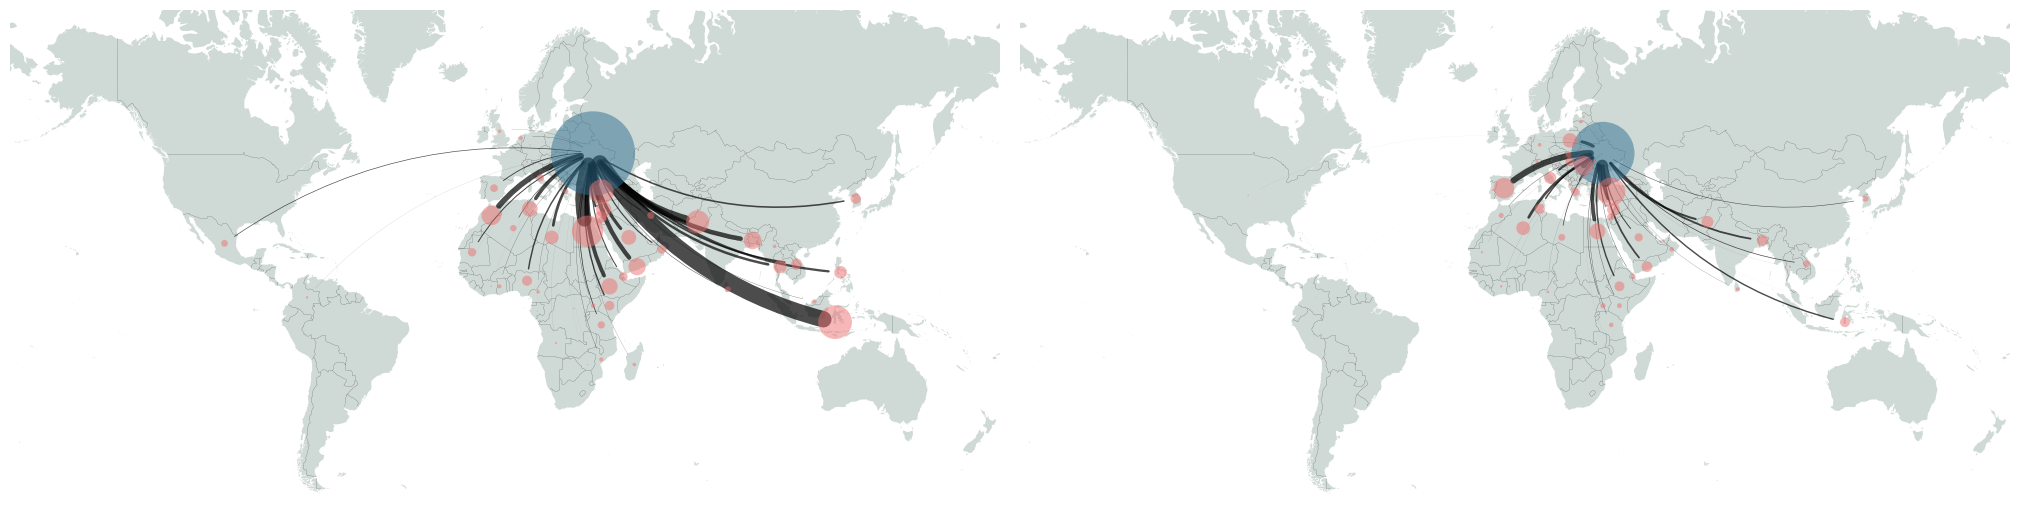

In [5]:
# Plot Ukrainian exports for 2021 and 2022
fig, axs = plt.subplots(figsize=(20, 10), subplot_kw=dict(projection=ccrs.Mercator()), ncols=2, gridspec_kw=dict(wspace=0.02, hspace=0))

_plot_props = dict(arrow_dict=dict(arrowstyle='-'), size_factor=0.1, width_factor=8e-2, add_sea=False, exporter_color=colors['c_darkblue'], importer_color=colors['c_red'], landcolor=colors['c_lightgrey'], fig=fig)

putils.plot_world_network(dsets["Wheat"]["FAO_data"].sel({"Source": ["UKR"], "Year": 2021}).mean("Reporter", skipna=True), ax=axs[0], **_plot_props)

putils.plot_world_network(dsets["Wheat"]["FAO_data"].sel({"Source": ["UKR"], "Year": 2022}).mean("Reporter", skipna=True), ax=axs[1], **_plot_props)

if img_dir:
    fig.savefig(f"{img_dir}/Wheat_Ukraine_1.png", pad_inches=0)

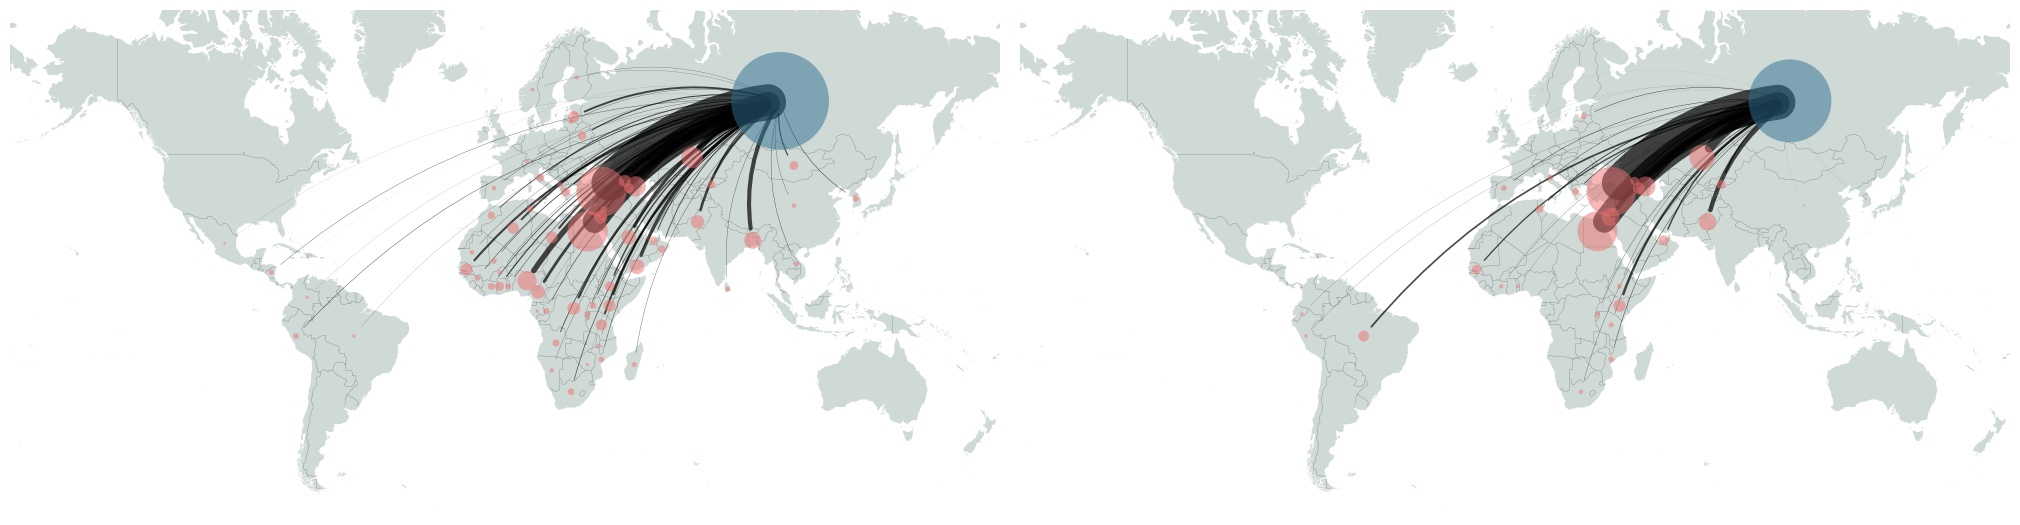

In [58]:
# Plot Russian exports for 2021 and 2022
fig, axs = plt.subplots(figsize=(20, 10), subplot_kw=dict(projection=ccrs.Mercator()), ncols=2, gridspec_kw=dict(wspace=0.02, hspace=0))

_plot_props = dict(arrow_dict=dict(arrowstyle='-'), size_factor=0.1, width_factor=8e-2, add_sea=False, exporter_color=colors['c_darkblue'], importer_color=colors['c_red'], landcolor=colors['c_lightgrey'], fig=fig)

putils.plot_world_network(dsets["Wheat"]["FAO_data"].sel({"Source": ["RUS"], "Year": 2021}).mean("Reporter", skipna=True), ax=axs[0], **_plot_props)

putils.plot_world_network(dsets["Wheat"]["FAO_data"].sel({"Source": ["RUS"], "Year": 2022}).mean("Reporter", skipna=True), ax=axs[1], **_plot_props)

if img_dir:
    fig.savefig(f"{img_dir}/Wheat_Russia_1.png", pad_inches=0)

## Changes in trade volume and cost

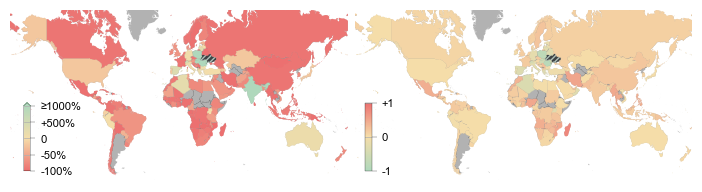

In [170]:
# Ukraine
fig, ax = putils.plot_trade_utility_comp_map(dsets["Wheat"]["Predictions"], year1=2021, year2=2022, source="UKR", colors=colors, figsize=(page_width, page_width/2))
fig.subplots_adjust(wspace=0.02)

In [171]:
if img_dir:
    fig.savefig(f"{img_dir}/Wheat_Ukraine_2.png", pad_inches=0)

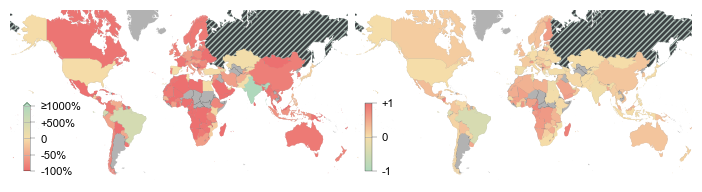

In [172]:
# Russia
fig, axs = putils.plot_trade_utility_comp_map(dsets["Wheat"]["Predictions"], year1=2021, year2=2022, source="RUS", colors=colors, figsize=(page_width, page_width/2))
fig.subplots_adjust(wspace=0.02)

In [173]:
if img_dir:
    fig.savefig(f"{img_dir}/Wheat_Russia_2.png", pad_inches=0)

## Drop in trade volume and utility, selected countries

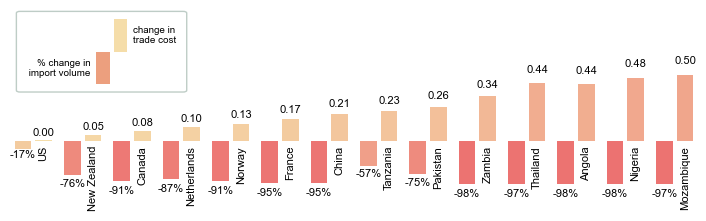

In [223]:
# Plot a comparison for Ukraine
fig, axs = putils.plot_trade_utility_comp(dsets["Wheat"]["Predictions"],
                                          source="UKR", year1=2021, year2=2022,
                                          destinations=["USA", "NZL", "CAN", "NLD", "NOR", "FRA", "CHN", "TZA", "PAK", "ZMB", "THA", "AGO", "NGA", "MOZ"],
                                          colors=colors, figsize=(page_width, 1.2))

# Add a legend
legend_ax = fig.add_axes([0.12, 0.85, 0.05, 0.6])
legend_ax.bar([0, 1], [-10, +10], color=[colors['c_orange'], colors['c_yellow']], lw=0)
legend_ax.text(-0.75, -5, '% change in\n import volume', ha='right', va='center', fontsize=7)
legend_ax.text(1.75, 5, 'change in\ntrade cost', ha='left', va='center', fontsize=7)
legend_ax.axis('off')
box_ax = fig.add_axes([0.0, 0.8, 0.26, 0.7], zorder=-2)
box_ax.xaxis.set_visible(False)
box_ax.yaxis.set_visible(False)
for s in ['top', 'bottom', 'right', 'left']:
    box_ax.spines[s].set_visible(False)
rect = patches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96, linewidth=1, edgecolor=colors['c_lightgrey'], alpha=0.8, facecolor='white', transform=box_ax.transAxes, boxstyle='Round, pad=0, rounding_size=0.02')
box_ax.add_patch(rect)

In [175]:
if img_dir:
    fig.savefig(f"{img_dir}/Wheat_Ukraine_3.pdf", pad_inches=0)

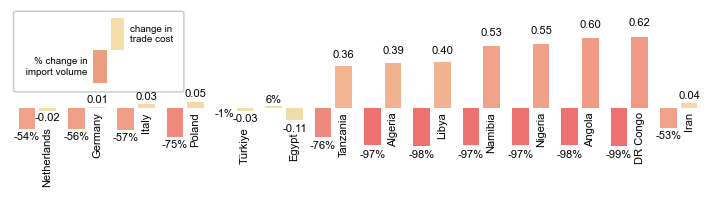

In [222]:
fig, axs = putils.plot_trade_utility_comp(dsets["Wheat"]["Predictions"],
                              source="RUS",
                              year1=2021, year2=2022,
                              destinations=["NLD", "DEU", "ITA", "POL", "CAN",  "FRA", "TZA", "DZA", "LBY", "NAM", "NGA", "AGO",  "COD", "CMR"],
                              colors=colors,
                              figsize=(page_width, 1.2))

# Add a legend
legend_ax = fig.add_axes([0.11, 0.54, 0.05, 0.6])
legend_ax.bar([0, 1], [-10, +10], color=[colors['c_orange'], colors['c_yellow']], lw=0)
legend_ax.text(-0.75, -5, '% change in\n import volume', ha='right', va='center', fontsize=7)
legend_ax.text(1.75, 5, 'change in\ntrade cost', ha='left', va='center', fontsize=7)
legend_ax.axis('off')
box_ax = fig.add_axes([-0.01, 0.48, 0.26, 0.7], zorder=-2)
box_ax.xaxis.set_visible(False)
box_ax.yaxis.set_visible(False)
for s in ['top', 'bottom', 'right', 'left']:
    box_ax.spines[s].set_visible(False)
rect = patches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96, linewidth=1, edgecolor=colors['c_lightgrey'], alpha=0.8, facecolor='white', transform=box_ax.transAxes, boxstyle='Round, pad=0, rounding_size=0.02')
box_ax.add_patch(rect)

In [177]:
if img_dir:
    fig.savefig(f"{img_dir}/Wheat_Russia_3.pdf", pad_inches=0)

## Macrotrends in Wheat markets, 2021--2022
We plot changes in cost and trade volumes as a function of GDP and geo-economic regions.

In [178]:
from plot_utils import get_relative_diff, get_diff
GDP_Data = xr.open_dataset("data/GDP_data.nc")
countries_by_region = pd.read_csv("data/countries_by_region.csv")
countries_by_region = countries_by_region.groupby('Region').agg(list).to_dict()['Country ISO']
countries_by_region['Eastern Asia'].append('TWN')

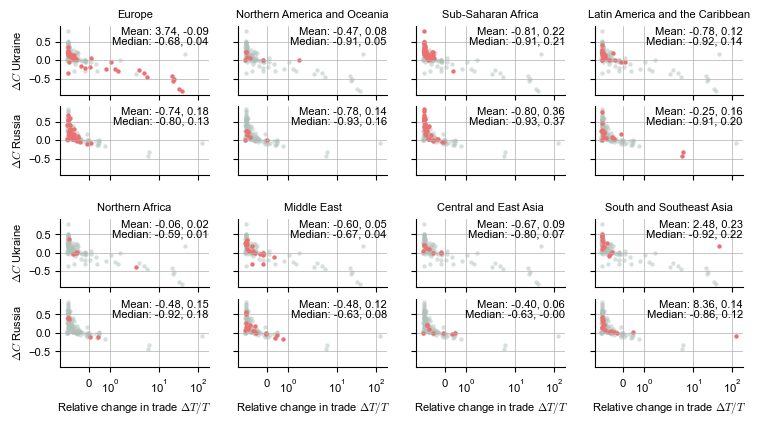

In [574]:
fig, axs = plt.subplots(ncols=4, nrows=5, figsize=(page_width, page_width/2), sharex=True, sharey=True, gridspec_kw={'height_ratios': [1, 1, 0.3, 1, 1]})

for row, source in enumerate(['UKR', 'RUS']):
    dT = dsets['Wheat']['Predictions']['mean'].sel({"Source": source, "Year": [2021, 2022], "variable": "T_pred"})
    dT = dT.diff('Year') / dT.sel({"Year": 2021})
    dC = dsets['Wheat']['Predictions']['mean'].sel({"Source": source, "Year": [2021, 2022], "variable": "C"}).diff('Year')
    for col, (color, regions) in enumerate([('c_red', ['Europe']), ('c_red', ['Northern America', 'Oceania']), ('c_red', ['Sub-Saharan Africa']), ('c_red', ['Latin America and the Caribbean'])]):
        _c = np.intersect1d(dT.Destination, np.concat([countries_by_region[k] for k in countries_by_region.keys() if k not in regions]))
        axs[row, col].scatter(dT.sel({"Destination": _c}), dC.sel({"Destination": _c}), s=10, c=colors['c_lightgrey'], alpha=0.5, lw=0)
        _c = np.intersect1d(dT.Destination, np.concat([countries_by_region[k] for k in countries_by_region.keys() if k in regions]))
        axs[row, col].scatter(dT.sel({"Destination": _c}), dC.sel({"Destination": _c}), s=10, lw=0, c=colors[color])
        axs[0, col].set_title(' and '.join(regions))
        axs[row, col].text(1, 1, f"Mean: {dT.sel({"Destination": _c}).mean().data.item():>.2f}, {dC.sel({"Destination": _c}).mean().data.item():>.2f}", transform=axs[row, col].transAxes, ha='right', va='top')
        axs[row, col].text(1, 0.85, f"Median: {dT.sel({"Destination": _c}).median().data.item():>.2f}, {dC.sel({"Destination": _c}).median().data.item():>.2f}", transform=axs[row, col].transAxes, ha='right', va='top')
    
    for col, (color, regions) in enumerate([('c_red', ['Northern Africa']), ('c_red', ['Western Asia']), ('c_red', ['Eastern Asia', 'Central Asia']), ('c_red', ['Southern Asia', 'South-eastern Asia'])]):
        _c = np.intersect1d(dT.Destination, np.concat([countries_by_region[k] for k in countries_by_region.keys() if k not in regions]))
        axs[row+3, col].scatter(dT.sel({"Destination": _c}), dC.sel({"Destination": _c}), s=10, c=colors['c_lightgrey'], alpha=0.5, lw=0)
        _c = np.intersect1d(dT.Destination, np.concat([countries_by_region[k] for k in countries_by_region.keys() if k in regions]))
        axs[row+3, col].scatter(dT.sel({"Destination": _c}), dC.sel({"Destination": _c}), s=10, lw=0, c=colors[color])
        axs[3, col].set_title(' and '.join(regions))
        axs[row+3, col].text(1, 1, f"Mean: {dT.sel({"Destination": _c}).mean().data.item():>.2f}, {dC.sel({"Destination": _c}).mean().data.item():>.2f}", transform=axs[row+3, col].transAxes, ha='right', va='top')
        axs[row+3, col].text(1, 0.85, f"Median: {dT.sel({"Destination": _c}).median().data.item():>.2f}, {dC.sel({"Destination": _c}).median().data.item():>.2f}", transform=axs[row+3, col].transAxes, ha='right', va='top')

axs[0, 0].set(xscale='symlog')
axs[0, 0].set(ylabel=r'$\Delta C$ Ukraine')
axs[1, 0].set(ylabel=r'$\Delta C$ Russia')

axs[3, 0].set(ylabel=r'$\Delta C$ Ukraine')
axs[4, 0].set(ylabel=r'$\Delta C$ Russia')
axs[3, 1].set(title='Middle East')
axs[3, 2].set(title='Central and East Asia')
axs[3, -1].set(title='South and Southeast Asia')

for col in range(4):
    axs[2, col].axis('off')
    axs[-1, col].set(xlabel=r'Relative change in trade $\Delta T / T$')

if img_dir:
    fig.savefig("Images/SI/Wheat_macrotrends_1.pdf", pad_inches=0)

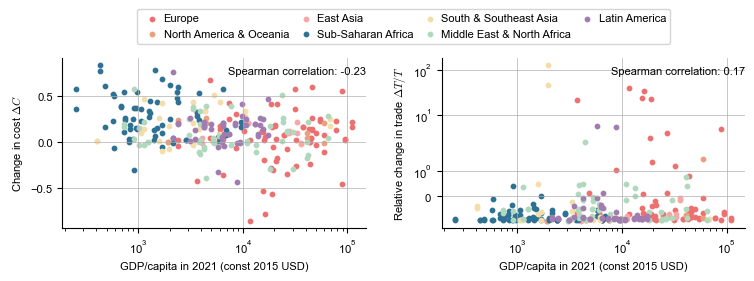

In [583]:
fig, axs = plt.subplots(ncols=2, figsize=(page_width, page_width/4), sharey=False, sharex=True, gridspec_kw={'wspace': 0.25})
dC = dsets['Wheat']['Predictions']['mean'].sel({"Source": ['UKR', 'RUS'], "Year": [2021, 2022], "variable": "C"}).diff('Year').drop_sel({"Destination": ['Other', 'Serbia and Montenegro']})
dT = dsets['Wheat']['Predictions']['mean'].sel({"Source": ['UKR', 'RUS'], "Year": [2021, 2022], "variable": "T_pred"}).drop_sel({"Destination": ['Other', 'Serbia and Montenegro']})
dT = dT.diff('Year')/dT.sel({"Year": 2021})
x = GDP_Data['GDP/capita (2015 USD)'].sel({'Year': 2021})
for idx, (color, label, region) in enumerate([
    (colors['c_red'], 'Europe', ['Europe']),
    (colors['c_orange'], 'North America & Oceania', ['Nothern America', 'Oceania']),
    (colors['c_pink'], 'East Asia', ['Eastern Asia']),
    (colors['c_darkblue'], 'Sub-Saharan Africa', ['Sub-Saharan Africa']),
    (colors['c_yellow'], 'South & Southeast Asia', ['Southern Asia', 'South-eastern Asia']),
    (colors['c_lightgreen'], 'Middle East & North Africa', ['Western Asia', 'Central Asia', 'Northern Africa']),
    (colors['c_purple'], 'Latin America', ['Latin America and the Caribbean'])
]):
    _c = np.intersect1d(dT.Destination, np.concat([countries_by_region[k] for k in countries_by_region.keys() if k in region]))
    _dC = dC.sel({"Destination": _c}).stack({'idx': ['Source', 'Destination']})
    _dT = dT.sel({"Destination": _c}).stack({'idx': ['Source', 'Destination']})
    axs[0].scatter(x.sel({"Country ISO": _dC.Destination}), _dC, color=color, s=10, label=label)
    axs[1].scatter(x.sel({"Country ISO": _dT.Destination}), _dT, color=color, s=10)
dC = dC.stack({"idx": ['Source', 'Destination']})
dT = dT.stack({"idx": ['Source', 'Destination']})
x = x.sel({"Country ISO": dT.Destination})
axs[0].text(1, 0.95, f"Spearman correlation: {scipy.stats.spearmanr(x.data.flatten(), dC.data.flatten()).statistic:>.2f}", transform=axs[0].transAxes, ha='right', va='top')
axs[1].text(1, 0.95, f"Spearman correlation: {scipy.stats.spearmanr(x.data.flatten()[~np.isnan(dT.data.flatten())], dT.data.flatten()[~np.isnan(dT.data.flatten())]).statistic:>.2f}", transform=axs[1].transAxes, ha='right', va='top')
axs[1].set(yscale='symlog', xscale='log', xlabel='GDP/capita in 2021 (const 2015 USD)', ylabel=r'Relative change in trade $\Delta T / T$')
axs[0].set(xlabel='GDP/capita in 2021 (const 2015 USD)', ylabel=r'Change in cost $\Delta C$')
fig.legend(ncols=4, bbox_to_anchor=(0.5, 1.05), loc='lower center', handletextpad=0, columnspacing=0.5)
fig.subplots_adjust(wspace=0.1)

if img_dir:
    fig.savefig("Images/SI/Wheat_macrotrends_2.pdf", pad_inches=0)

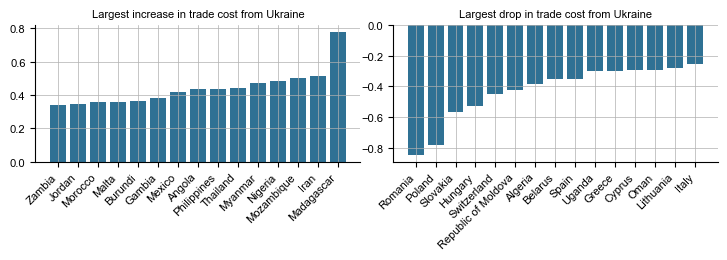

In [576]:
# Largest drops in trade and utility
fig, axs = plt.subplots(ncols=2, gridspec_kw=dict(hspace=0.4, wspace=0.1), figsize=(page_width, page_width/5))
n=15
axs[0].set_title("Largest increase in trade cost from Ukraine")
axs[1].set_title("Largest drop in trade cost from Ukraine")


_wheat_c = dsets["Wheat"]["Predictions"]["mean"].sel({"variable": "C"}).drop_sel({"Destination": ["Serbia and Montenegro", "Other"]})
_util_drop_UKR = get_diff(_wheat_c, source="UKR", year1=2021, year2=2022).isel({"Destination": get_diff(_wheat_c, source="UKR", year1=2021, year2=2022).squeeze().argsort().data}).squeeze().dropna("Destination")
axs[0].bar([putils.property_from_iso3(iso, item="Name") for iso in _util_drop_UKR.coords["Destination"].data[-n:]], _util_drop_UKR[-n:])
axs[1].bar([putils.property_from_iso3(iso, item="Name") for iso in _util_drop_UKR.coords["Destination"].data[:n]], _util_drop_UKR[:n])

for idx in [0, 1]:
    axs[idx].set_xticks(axs[idx].get_xticks(), [s._text for s in axs[idx].get_xticklabels()], rotation=45, ha='right')

if img_dir:
    fig.savefig("Images/SI/Wheat_macrotrends_3.pdf", pad_inches=0)

# Trade in Southeast Asia and Asia-Pacific
## Barley

(<Figure size 2000x1000 with 2 Axes>, <GeoAxes: >)

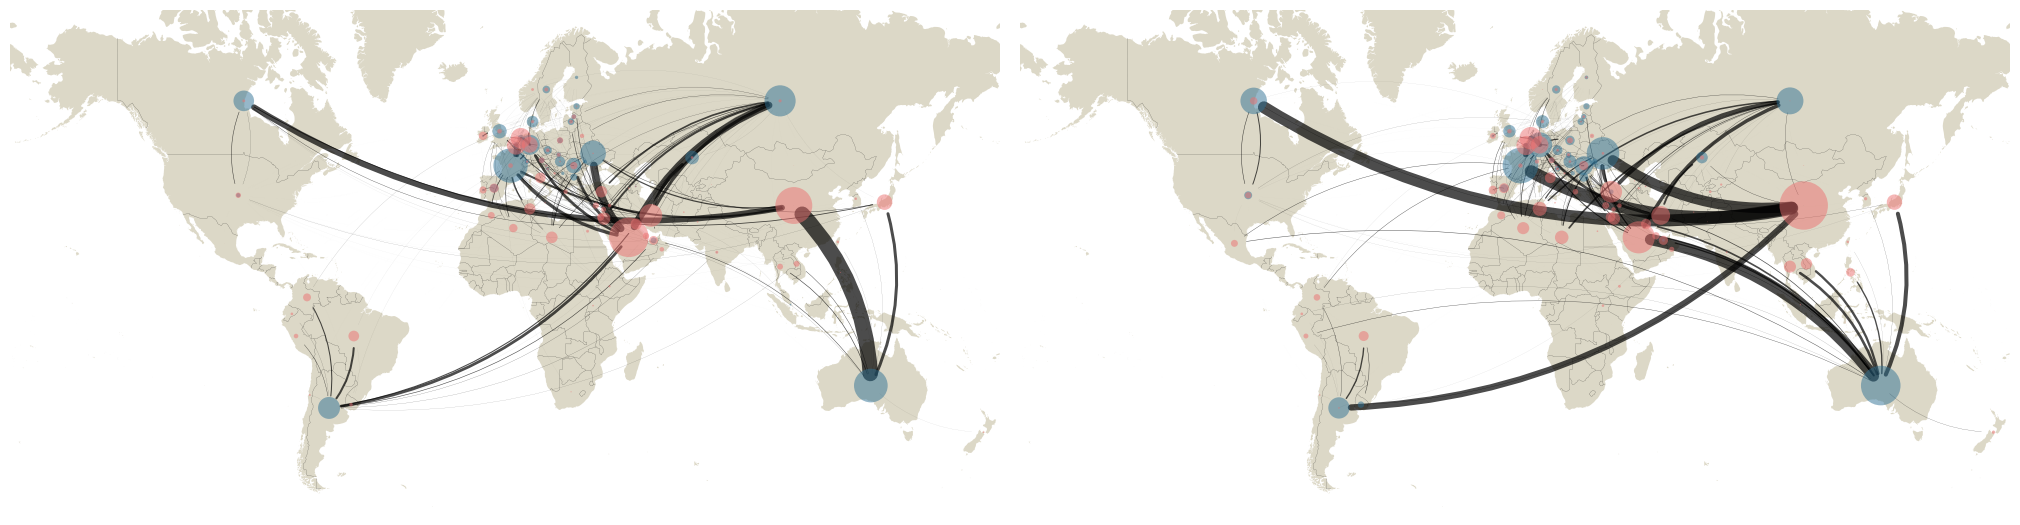

In [6]:
# Compare the global barley trade, 2018 and 2021
fig, axs = plt.subplots(figsize=(20, 10), subplot_kw=dict(projection=ccrs.Mercator()), ncols=2, gridspec_kw=dict(wspace=0.02, hspace=0))
_plot_props = dict(fig=fig, arrow_dict=dict(arrowstyle='-'), size_factor=0.05, width_factor=5e-2, add_sea=False, landcolor=colors['c_lightgrey'], exporter_color=colors['c_darkblue'], importer_color=colors['c_red'])

putils.plot_world_network(dsets["Barley"]["FAO_data"].sel({"Year": 2018}).mean("Reporter", skipna=True), ax=axs[0], **_plot_props)

putils.plot_world_network(dsets["Barley"]["FAO_data"].sel({"Year": 2021}).mean("Reporter", skipna=True), ax=axs[1], **_plot_props)

In [180]:
if img_dir:
    fig.savefig("Images/Barley_trade_map.png", pad_inches=0)

Missing: Serbia and Montenegro
Missing: Other
Missing: Serbia and Montenegro
Missing: Other


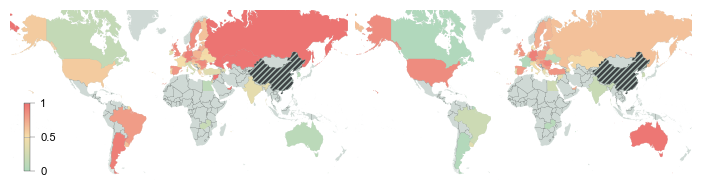

In [181]:
# Plot the change in trade utility with China
fig, axs = plt.subplots(figsize=(page_width, page_width/2), subplot_kw=dict(projection=ccrs.Mercator()), ncols=2, gridspec_kw=dict(wspace=0.02, hspace=0))

# Only consider Chinese imports
china_imports = dsets["Barley"]["Predictions"]["mean"].sel({"Destination": "CHN"}, drop=True)
china_imports = china_imports.sel({"variable": "C"})

# Plot two years
for year, ax in [(2018, axs[0]), (2021, axs[1])]:

    # Plot the background
    putils.plot_background_map(fig, ax, borders_lw = 0.1, add_sea=False, landcolor=colors['c_lightgrey'])

    _dset = china_imports.sel({"Year": year})

    # Highlight trading partners
    for source in _dset.coords["Source"].data:
        if source in list(world['ISO_A3_EH']):
            if source == "CHN":
                world[world['ISO_A3_EH'] == source].plot(color=colors['c_darkgrey'], ax=ax, zorder=0, lw=0.1, edgecolor=colors['c_lightgrey'], hatch=r"//////")
            else:
                _color = cm_GrYeRe.map_to_color(_dset.sel({"Source": source}))
                world[world['ISO_A3_EH'] == source].plot(color=_color, ax=ax, zorder=0, lw=0.1, edgecolor=_color)
        else:
            print(f"Missing: {source}")

# Add a colorbar
cax = fig.add_axes([0.02, 0.28, 0.01, 0.2])
cbar = colorbar.Colorbar(cax, cmap=cm_GrYeRe.cmap, orientation='vertical', location='right', drawedges=False)
cbar.set_ticks(ticks=[0, 0.5, 1], labels=[0, 0.5, 1])
cbar.outline.set_linewidth(0.2)
cax.tick_params(width=0.2)

In [182]:
if img_dir:
    fig.savefig("Images/Barley_trade_map_2.png", pad_inches=0)

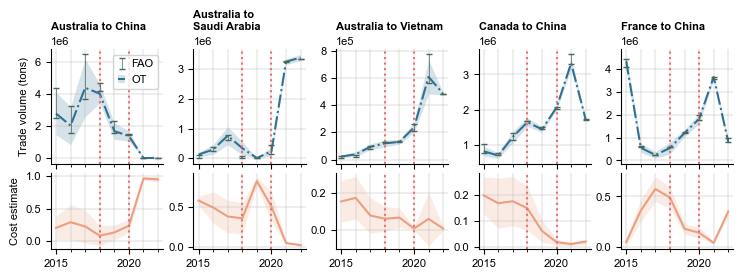

In [183]:
# Compare the barley trade
from matplotlib.ticker import MultipleLocator
fig, axs = plt.subplots(ncols=5, nrows=2, figsize=(page_width, 2), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})

handles = []
for idx, (ex, im) in enumerate([("AUS", "CHN"), ("AUS", "SAU"), ("AUS", "VNM"), ("CAN", "CHN"), ("FRA", "CHN")]):

    ax = axs[0, idx]
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    # True transport flow (quantity)
    _T = dsets["Barley"]["FAO_data"].sel({"Source": ex, "Destination": im}).dropna("Year").sel({"Year": range(2015, 2023)})

    # Plot the true quantity flow
    _d = ax.errorbar(_T.coords["Year"], _T.mean("Reporter"), yerr=_T.std("Reporter"), lw=0, elinewidth=0.5, capsize=2, zorder=5,
                     color=colors['c_darkgreen'])

    if idx == 0:
        handles.append((_d))

    # Plot the predicted transport flow
    _T_pred = dsets["Barley"]["Predictions"].sel({"variable": "T_pred", "Source": ex, "Destination": im}).sel({"Year": range(2015, 2023)})
    _fb = ax.fill_between(
        _T_pred.coords["Year"],
        _T_pred["mean"] - _T_pred["std"],
        _T_pred["mean"] + _T_pred["std"],
        alpha=0.2, lw=0, color=colors['c_darkblue']
    )
    _l = ax.plot(_T_pred.coords["Year"], _T_pred["mean"], color=colors['c_darkblue'], linestyle='-.')
    if idx == 0:
        handles += [(_fb, _l[0])]

    ax.grid(which='both', axis='both', lw=0.3)
    ax.grid(True, which='both')
    ax.set_title(f"{putils.property_from_iso3(ex, item='Name')} to {putils.property_from_iso3(im, item='Name')}", y=1.1, x=0, **axes_title_props)
    ax = axs[1, idx]

    # Plot the predicted cost
    _C_pred = dsets["Barley"]["Predictions"].sel({"variable": "C", "Source": ex, "Destination": im, "Year": range(2015, 2023)})
    _fb = ax.fill_between(_C_pred.coords["Year"],
                    _C_pred["mean"]-_C_pred["std"],
                    _C_pred["mean"]+_C_pred["std"], alpha=0.2, color=colors['c_orange'], lw=0)
    _l = ax.plot(_C_pred.coords["Year"], _C_pred["mean"], label="Cost", color=colors['c_orange'])
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(which='both', axis='both', lw=0.3)
    ax.grid(True, axis='x', which='both')

# Add legend and labels
axs[0, 0].legend(handles=handles, labels=["FAO", "OT"], loc='upper right', handlelength=0.7, handletextpad=0.5)
axs[0, 0].set_ylabel("Trade volume (tons)")
axs[1, 0].set_ylabel("Cost estimate")
axs[0, 1].set_title("Australia to\nSaudi Arabia", y=1.1, x=0, **axes_title_props)
for ax in axs.flatten():
    for y in [2018, 2020]:
        ax.axvline(y, linestyle='dotted', lw=1.5, color=colors['c_red'])
fig.subplots_adjust(hspace=0.1, wspace=0.27)

In [184]:
if img_dir:
    fig.savefig("Images/Australia_barley.pdf", pad_inches=0)

## Australia-China trade

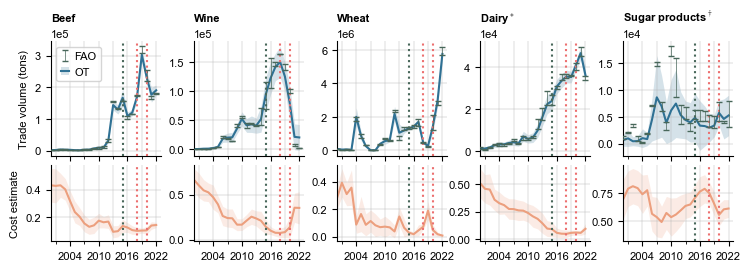

In [185]:
fig, axs = plt.subplots(ncols=5, nrows=2, figsize=(page_width, 2), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})

im, ex = "CHN", "AUS"

handles = []
for idx, commodity in enumerate(["Beef", "Wine", "Wheat", "Dairy", "Sugar"]):

    ax = axs[0, idx]
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    # Plot the true quantity flow (FAO data)
    _T = dsets[commodity]["FAO_data"].sel({"Source": ex, "Destination": im}).dropna("Year")
    _d = ax.errorbar(_T.coords["Year"], _T.mean("Reporter"), yerr=_T.std("Reporter"), color=colors['c_darkgreen'], lw=0, elinewidth=0.5, capsize=2, label=f"FAO data", zorder=5)

    # Plot the predicted transport flow
    _T_pred = dsets[commodity]["Predictions"].sel({"variable": "T_pred", "Source": ex, "Destination": im})
    _fb = ax.fill_between(
        _T_pred.coords["Year"],
        _T_pred["mean"] - _T_pred["std"],
        _T_pred["mean"] + _T_pred["std"],
        alpha=0.2, lw=0, color=colors['c_darkblue']
    )
    _l = ax.plot(_T_pred.coords["Year"], _T_pred["mean"], color=colors['c_darkblue'], linestyle='-')
    if idx == 0:
        handles += [_d, (_fb, _l[0])]

    ax.set_title(commodity, x=0, y=1.1, **axes_title_props)

    ax.xaxis.set_major_locator(MultipleLocator(6))
    ax.xaxis.set_minor_locator(MultipleLocator(3))
    ax.grid(axis='both', which='both', lw=0.3)
    ax.grid(True, axis='x', which='both')

    # Plot the predicted clost
    ax = axs[1, idx]
    _C_pred = dsets[commodity]["Predictions"].sel({"variable": "C", "Source": ex, "Destination": im})
    _fb = ax.fill_between(_C_pred.coords["Year"],
                    _C_pred["mean"]-_C_pred["std"], # Remove lower bound on log-scale
                    _C_pred["mean"]+_C_pred["std"], alpha=0.2, color=colors['c_orange'], lw=0)
    _l = ax.plot(_C_pred.coords["Year"], _C_pred["mean"], label="Cost", color=colors['c_orange'])
    ax.set_xlim(2000, 2023)
    ax.xaxis.set_major_locator(MultipleLocator(6))
    ax.xaxis.set_minor_locator(MultipleLocator(3))
    ax.grid(axis='both', which='both', lw=0.3)
    ax.grid(True, axis='x', which='both')

axs[0, 0].legend(handles=handles, labels=["FAO", "OT"], handlelength=0.7, handletextpad=0.5)

# Mark significant events
for ax in axs.flatten():
    ax.axvline(2015, linestyle='dotted', lw=1.5, color=colors['c_darkgreen'])
    for y in [2018, 2020]:
        ax.axvline(y, linestyle='dotted', lw=1.5, color=colors['c_red'])
axs[0, 0].set_ylabel("Trade volume (tons)")
axs[1, 0].set_ylabel("Cost estimate")

axs[0, 3].set_title("Dairy$^*$", x=0, y=1.1, **axes_title_props)
axs[0, 4].set_title(r"Sugar products$^\dagger$", x=0, y=1.1, **axes_title_props)
fig.subplots_adjust(hspace=0.1, wspace=0.3)

In [186]:
if img_dir:
    fig.savefig("Images/Australia_China.pdf", pad_inches=0)

## Sugar

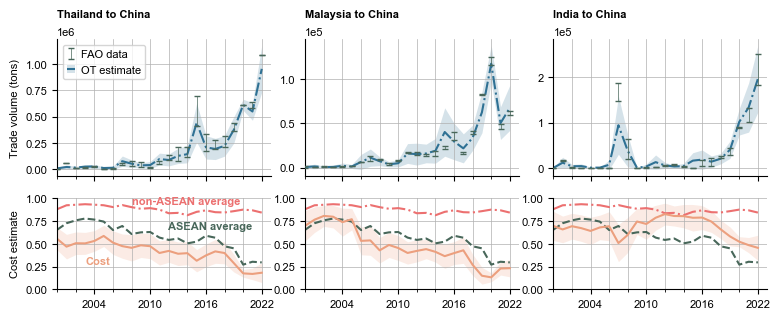

In [187]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(7.1, 2.5), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})

# Plot the ASEAN and non-ASEAN means
ASEAN_mean = dsets["Sugar"]["Predictions"]["mean"].sel({"Source": ["THA", "IDN", "MYS", "LAO", "VNM", "PHL"]}).mean("Source").sel({"variable": "C", "Destination": "CHN"})
non_ASEAN_mean = dsets["Sugar"]["Predictions"]["mean"].sel({"Source": [c for c in dsets["Sugar"]["Predictions"].coords["Source"].data if c not in ["THA", "IDN", "MYS", "LAO", "VNM", "PHL"]]}).mean("Source").sel({"variable": "C", "Destination": "CHN"})
for idx in [0, 1, 2]:
    _mA = axs[1, idx].plot(ASEAN_mean.coords["Year"], ASEAN_mean, label="ASEAN mean", 
                        linestyle='dashed', color=colors['c_darkgreen'])
    _mnA = axs[1, idx].plot(ASEAN_mean.coords["Year"], non_ASEAN_mean, label="non-ASEAN mean", 
                        linestyle='-.', color=colors['c_red'])

importer = "CHN"

# Collect the handles for the legend
handles = []

for idx, exporter in enumerate(["THA", "MYS", "IND"]):

    ax = axs[0, idx]
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    # Plot the true quantity flow (FAO data)
    _T = dsets["Sugar"]["FAO_data"].sel({"Source": exporter, "Destination": importer}).dropna("Year")
    _d = ax.errorbar(_T.coords["Year"], _T.mean("Reporter"), yerr=_T.std("Reporter"), color=colors['c_darkgreen'], lw=0, elinewidth=0.5, capsize=2, label=f"FAO data", zorder=5)

    # Plot the predicted transport flow
    _T_pred = dsets["Sugar"]["Predictions"].sel({"variable": "T_pred", "Source": exporter, "Destination": importer})
    _fb = ax.fill_between(
        _T_pred.coords["Year"], 
        _T_pred["mean"] - _T_pred["std"], 
        _T_pred["mean"] + _T_pred["std"], 
        alpha=0.2, lw=0, color=colors['c_darkblue']
    )
    _l = ax.plot(_T_pred.coords["Year"], _T_pred["mean"], color=colors['c_darkblue'], linestyle='-.')
    if idx == 0:
        handles += [_d, (_fb, _l[0])]  
        
    # Set the title
    ax.set_title(f"{putils.property_from_iso3(exporter, item='Name')} to {putils.property_from_iso3(importer, item='Name')}", y=1.1, x=0, **axes_title_props)

    # Plot the predicted cost
    ax = axs[1, idx]
    _C_pred = dsets["Sugar"]["Predictions"].sel({"variable": "C", "Source": exporter, "Destination": importer})
    _fb = ax.fill_between(_C_pred.coords["Year"], 
                    _C_pred["mean"]-_C_pred["std"], # Remove lower bound on log-scale
                    _C_pred["mean"]+_C_pred["std"], alpha=0.2, color=colors['c_orange'], lw=0)
    _l = ax.plot(_C_pred.coords["Year"], _C_pred["mean"], label="Cost", color=colors['c_orange'])
    ax.set_ylim(0, 1)

for ax in axs.flatten():
    ax.set_xlim(2000, 2023)
    ax.xaxis.set_major_locator(MultipleLocator(6))
    ax.xaxis.set_minor_locator(MultipleLocator(2))
    ax.grid(True, axis='x', which='both')

# Add a legend and labels
axs[0, 0].legend(handles=handles, labels=["FAO data", "OT estimate"], handlelength=0.7, handletextpad=0.5)
axs[0, 0].set_ylabel("Trade volume (tons)")
axs[1, 0].set_ylabel("Cost estimate")

# Add annotations
axs[1, 0].annotate('Cost', (2003, 0.28), ha='left', color=colors['c_orange'], fontweight='bold')
axs[1, 0].annotate('ASEAN average', (2021, 0.66), ha='right', color=colors['c_darkgreen'], fontweight='bold')
axs[1, 0].annotate('non-ASEAN average', (2008, 0.94), color=colors['c_red'], fontweight='bold')

fig.subplots_adjust(hspace=0.2, wspace=0.16)

In [188]:
if img_dir:
    fig.savefig("Images/China_sugar.pdf", pad_inches=0)

## Soya beans

(<Figure size 2000x1000 with 2 Axes>, <GeoAxes: >)

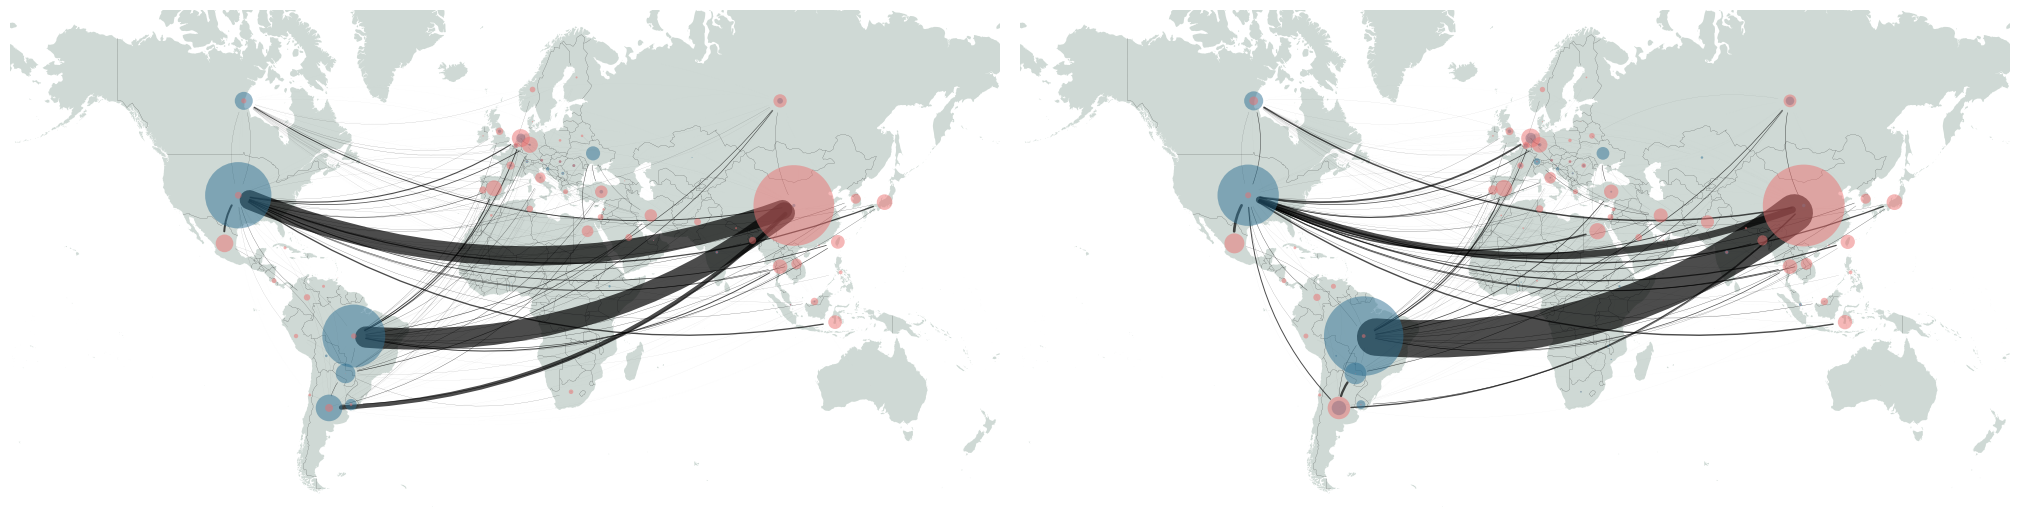

In [189]:
# Compare the global soya bean trade, 2016--2018
fig, axs = plt.subplots(figsize=(20, 10), subplot_kw=dict(projection=ccrs.Mercator()), ncols=2, gridspec_kw=dict(wspace=0.02, hspace=0))
_plot_props = dict(fig=fig, arrow_dict=dict(arrowstyle='-'), size_factor=0.02, width_factor=8e-3, add_sea=False, landcolor=colors['c_lightgrey'], exporter_color=colors['c_darkblue'], importer_color=colors['c_red'])

putils.plot_world_network(dsets["Soya"]["FAO_data"].sel({"Year": 2016}).mean("Reporter", skipna=True), ax=axs[0], **_plot_props)

putils.plot_world_network(dsets["Soya"]["FAO_data"].sel({"Year": 2018}).mean("Reporter", skipna=True), ax=axs[1], **_plot_props)

In [190]:
if img_dir:
    fig.savefig("Images/Soya_trade_map.png", pad_inches=0)

Text(0, 0.5, 'Cost estimate')

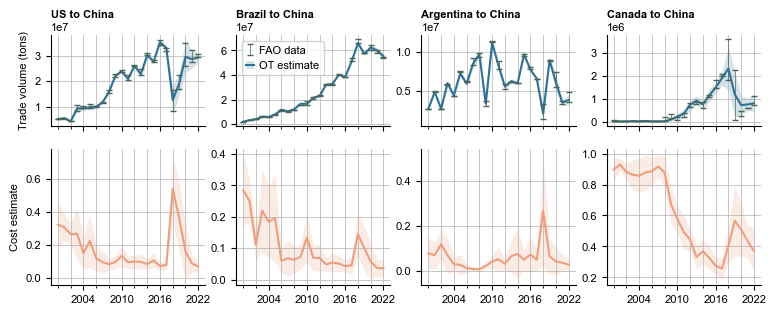

In [192]:
# Comparison of exports to China
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(7.1, 2.5), sharex=True, gridspec_kw={'height_ratios': [1, 1.5], 'hspace': 0.2, 'wspace': 0.2})

im = "CHN"

handles = []
for idx, ex in enumerate(["USA", "BRA", "ARG", "CAN"]):
    
    ax = axs[0, idx]
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    # True transport flow (quantity)
    _T = dsets["Soya"]["FAO_data"].sel({"Source": ex, "Destination": im}).dropna("Year")

    # Plot the true quantity flow
    _d = ax.errorbar(_T.coords["Year"], _T.mean("Reporter"), yerr=_T.std("Reporter"), color=colors['c_darkgreen'], lw=0, elinewidth=0.5, capsize=2, label=f"FAO data", zorder=5)

    # Plot the predicted transport flow
    _T_pred = dsets["Soya"]["Predictions"].sel({"variable": "T_pred", "Source": ex, "Destination": im})
    _fb = ax.fill_between(
        _T_pred.coords["Year"], 
        _T_pred["mean"] - _T_pred["std"], 
        _T_pred["mean"] + _T_pred["std"], 
        alpha=0.2, lw=0, color=colors['c_darkblue']
    )
    _l = ax.plot(_T_pred.coords["Year"], _T_pred["mean"], color=colors['c_darkblue'], linestyle='-')
    
    ax.set_title(f"{putils.property_from_iso3(ex, item='Name')} to {putils.property_from_iso3(im, item='Name')}", y=1.1, x=0.0, ha='left', fontweight='bold')
    if idx == 0:
        handles += [_d, (_fb, _l[0])]
    ax.xaxis.set_major_locator(MultipleLocator(6))
    ax.xaxis.set_minor_locator(MultipleLocator(2))
    ax.grid(True, axis='x', which='both')
    ax = axs[1, idx]
    _C_pred = dsets["Soya"]["Predictions"].sel({"variable": "C", "Source": ex, "Destination": im})
    _fb = ax.fill_between(_C_pred.coords["Year"], 
                    _C_pred["mean"]-_C_pred["std"], # Remove lower bound on log-scale
                    _C_pred["mean"]+_C_pred["std"], alpha=0.2, color=colors['c_orange'], lw=0)
    _l = ax.plot(_C_pred.coords["Year"], _C_pred["mean"], label="Cost", color=colors['c_orange'])

    ax.xaxis.set_major_locator(MultipleLocator(6))
    ax.xaxis.set_minor_locator(MultipleLocator(2))
    ax.grid(True, axis='x', which='both')

axs[0, 1].legend(handles=handles, labels=["FAO data", "OT estimate"], handlelength=0.7, handletextpad=0.5)
 
axs[0, 0].set_ylabel("Trade volume (tons)")
axs[1, 0].set_ylabel("Cost estimate")

In [193]:
if img_dir:
    fig.savefig("Images/Soya_trade.pdf", pad_inches=0)

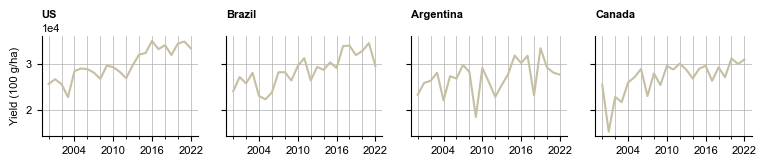

In [194]:
# Plot the yields for different countries
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(7.1, 1), sharex=True, sharey=True)

for idx, country in enumerate(["USA", "BRA", "ARG", "CAN"]):
    axs[idx].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    yields.sel({"Item": "Soya beans; 100 g/ha", "Area": country, "Year": range(2000, 2023)}).plot(ax=axs[idx], color=colors['c_lightbrown'])
    axs[idx].set(ylabel=None, xlabel=None)
    axs[idx].set_title(f"{putils.property_from_iso3(country, item='Name')}", fontweight='bold', ha='left', x=0.0, y=1.1)
    axs[idx].xaxis.set_major_locator(MultipleLocator(6))
    axs[idx].xaxis.set_minor_locator(MultipleLocator(2))
    axs[idx].grid(True, axis='x', which='both')
axs[0].set_ylabel("Yield (100 g/ha)")

fig.subplots_adjust(hspace=0.2, wspace=0.18, top=1, bottom=0, left=0, right=1)

In [195]:
if img_dir:
    fig.savefig("Images/Soya_yield.pdf", pad_inches=0)

# Brexit
## Vegetables

In [59]:
def _get_predictions(comm):
    return dsets[comm]["Predictions"]

Vegetable_diff = _get_predictions("Lettuce")["mean"].sel({"Year": [2016, 2022], "variable": "C"}, drop=True).diff("Year").sel({"Destination": ["GBR", "IRL"]})
Vegetable_trade_diff = (_get_predictions("Lettuce")["mean"].sel({"Year": [2016, 2022], "variable": "T_pred"}).diff("Year") / _get_predictions("Lettuce")["mean"].sel({"Year": 2016, "variable": "T_pred"}).squeeze().data).sel({"Destination": ["GBR", "IRL"]})

Tomato_diff = _get_predictions("Tomatoes")["mean"].sel({"Year": [2016, 2022], "variable": "C"}, drop=True).diff("Year").sel({"Destination": ["GBR", "IRL"]})
Tomato_trade_diff = (_get_predictions("Tomatoes")["mean"].sel({"Year": [2016, 2022], "variable": "T_pred"}).diff("Year") / _get_predictions("Tomatoes")["mean"].sel({"Year": 2016, "variable": "T_pred"}).squeeze().data).sel({"Destination": ["GBR", "IRL"]})

Cucumber_diff = _get_predictions("Cucumbers")["mean"].sel({"Year": [2016, 2022], "variable": "C"}, drop=True).diff("Year").sel({"Destination": ["GBR", "IRL"]})
Cucumber_trade_diff = (_get_predictions("Cucumbers")["mean"].sel({"Year": [2016, 2022], "variable": "T_pred"}).diff("Year") / _get_predictions("Cucumbers")["mean"].sel({"Year": 2016, "variable": "T_pred"}).squeeze().data).sel({"Destination": ["GBR", "IRL"]})

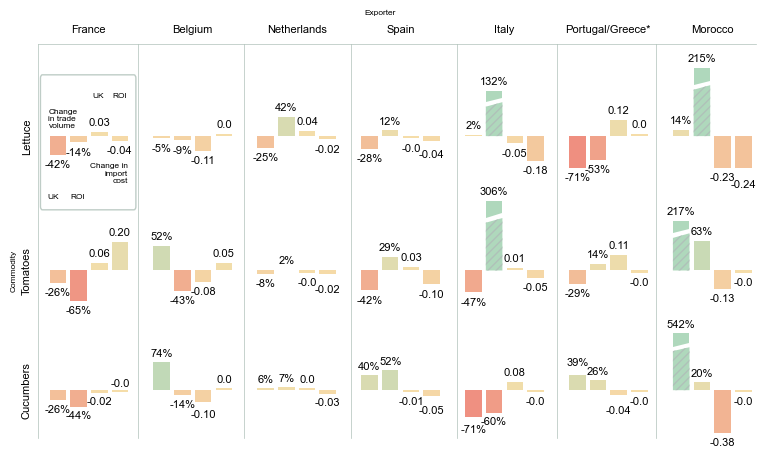

In [67]:
# Comparison panel of vegetable trade
cm = ColorManager(
    cmap={'continuous': True, 'from_values': {0: colors['c_red'], 0.5: colors['c_yellow'], 1: colors['c_lightgreen'], }},
    vmin=-1,
    vmax=+1
)

fig, axs = plt.subplots(ncols=7, nrows=3, figsize=(7.1, 3.75), sharey='row')
for row, (_comm, _country_list) in enumerate([
                            ("Vegetable", ["FRA", "BEL", "NLD", "ESP", "ITA", "PRT", "MAR"]), 
                            ("Tomatoes", ["FRA", "BEL", "NLD", "ESP", "ITA", "PRT", "MAR"]), 
                            ("Cucumbers", ["FRA", "BEL", "NLD", "ESP", "ITA", "GRC", "MAR"])
]):
    
    _trade_diff = Vegetable_trade_diff if _comm == "Vegetable" else Tomato_trade_diff if _comm == "Tomatoes" else Cucumber_trade_diff
    _diff = Vegetable_diff if _comm == "Vegetable" else Tomato_diff if _comm == "Tomatoes" else Cucumber_diff
    _trade_diff = _trade_diff.sel({"Source": _country_list})
    _diff = _diff.sel({"Source": _country_list})
    
    for col, country in enumerate(_country_list):

        _T = _trade_diff.sel({"Source": country, "Destination": "GBR"}).data[0]
        if _T <= 1.0:
            _rect = axs[row, col].bar([0], [_T], color=cm.map_to_color(_T), lw=0)
            _patch = _rect.get_children()[0]
            _x, _y = 0, _patch._height
        else:
            _h = max(1., 1.5*_T / _trade_diff.data.max())
            _rect_1 = patches.Polygon([(-0.4, 0), (-0.4, 0.75*_h-0.1), (0.4, 0.75*_h), (0.4, 0)], color=cm.map_to_color(_T), lw=0, ec=colors['c_lightgrey'], hatch='////')
            _rect = patches.Polygon([(-0.4, 0.75*_h), (-0.4, _h), (0.4, _h), (0.4, 0.75*_h+0.1)], color=cm.map_to_color(_T), lw=0)
            axs[row, col].add_patch(_rect_1)
            axs[row, col].add_patch(_rect)
            _x, _y = 0, _h
        
        axs[row, col].text(_x, _y + np.sign(_y)*0.1, "{t:.0f}%".format(t=100*_T), ha='center', va='top' if _y < 0 else 'bottom')
        
        _T = _trade_diff.sel({"Source": country, "Destination": "IRL"}).data[0]
        if _T <= 1.0:
            _rect = axs[row, col].bar([1], [_T], color=cm.map_to_color(_T), lw=0)
            _patch = _rect.get_children()[0]
            _x, _y = 1, _patch._height
        else:
            _h = max(1., 1.5*_T / _trade_diff.data.max())
            _rect_1 = patches.Polygon([(0.6, 0), (0.6, 0.75*_h-0.1), (1.4, 0.75*_h), (1.4, 0)], color=cm.map_to_color(_T), lw=0, ec=colors['c_lightgrey'], hatch='////')
            _rect = patches.Polygon([(0.6, 0.75*_h), (0.6, _h), (1.4, _h), (1.4, 0.75*_h+0.1)], color=cm.map_to_color(_T), lw=0)
            axs[row, col].add_patch(_rect_1)
            axs[row, col].add_patch(_rect)
            _x, _y = 1, _h
        axs[row, col].text(_x, _y + np.sign(_y)*0.1, "{t:.0f}%".format(t=100*_T), ha='center', va='top' if _T < 0 else 'bottom')
            
        _C = _diff.sel({"Destination": "GBR", "Source": country}).squeeze().data
        _rect = axs[row, col].bar([2], [np.sign(_C)*max(3*abs(_C), 0.05)], color=cm.map_to_color(_C) if _C > 0 else cm.map_to_color(_C), lw=0)
        _patch = _rect.get_children()[0]
        _x, _y = 2, _patch._height
        axs[row, col].text(_x, _y + np.sign(_y)*0.1, f"{_C:>.2f}" if abs(_C) >= 0.01 else f"{_C:>.1f}", ha='center', va='bottom' if _C > 0 else 'top')
    
        _C = _diff.sel({"Destination": "IRL", "Source": country}).squeeze().data
        _rect = axs[row, col].bar([3], [np.sign(_C)*max(3*abs(_C), 0.05)], color=cm.map_to_color(_C) if _C > 0 else cm.map_to_color(_C), lw=0)
        _patch = _rect.get_children()[0]
        _x, _y = 3, _patch._height
        
        axs[row, col].text(_x, _y + np.sign(_y)*0.1, f"{_C:>.2f}" if abs(_C) >= 0.01 else f"{_C:>.1f}", ha='center', va='bottom' if _C > 0 else 'top')
        
        if row == 0:
            axs[row, col].set_title(putils.property_from_iso3(country, item='Name', correct=True), y=1.2)
        axs[row, col].axis('off')

axs[0, 0].text(-1.5, 0., 'Lettuce', rotation=90, ha='center', va='center')
axs[1, 0].text(-1.5, 0., 'Tomatoes', rotation=90, ha='center', va='center')
axs[2, 0].text(-1.5, 0., 'Cucumbers', rotation=90, ha='center', va='center')
axs[0, 3].text(0.5, 2.8, 'Exporter', ha='center', va='top', fontsize=6)
axs[1, 0].text(-2, 0, 'Commodity', ha='right', va='center', fontsize=6, rotation=90)
axs[0, 5].set_title("Portugal/Greece*", y=1.2)

box_ax = fig.add_axes([-0.01, 0.6, 0.14, 0.45], zorder=-2)
box_ax.xaxis.set_visible(False)
box_ax.yaxis.set_visible(False)
for s in ['top', 'bottom', 'right', 'left']:
    box_ax.spines[s].set_visible(False)


rect = patches.FancyBboxPatch((0.02, 0.02), 0.96, 0.8, linewidth=1, edgecolor=colors['c_lightgrey'], alpha=0.8, facecolor='white', transform=box_ax.transAxes, boxstyle='Round, pad=0, rounding_size=0.02')

# Add the patch to the Axes
box_ax.add_patch(rect)
box_ax.patch.set(fill=None)
box_ax.text(0.15, 0.1, 'UK', ha='center', va='center', fontsize=6)
box_ax.text(0.40, 0.1, 'ROI', ha='center', va='center', fontsize=6)
box_ax.text(0.60, 0.7, 'UK', ha='center', va='center', fontsize=6)
box_ax.text(0.82, 0.7, 'ROI', ha='center', va='center', fontsize=6)
box_ax.text(0.1, 0.5, 'Change\nin trade\nvolume', ha='left', va='bottom', fontsize=6)
box_ax.text(0.90, 0.3, 'Change in\nimport\ncost', ha='right', va='top', fontsize=6)

import matplotlib.lines as lines

for _line_x in [-0.01, 0.13, 0.28, 0.43, 0.58, 0.72, 0.86]:
    fig.add_artist(lines.Line2D([_line_x, _line_x], [0, 1.05], c=colors['c_lightgrey'], lw=0.5))
fig.add_artist(lines.Line2D([-0.01, 1.], [1.05, 1.05], c=colors['c_lightgrey'], lw=0.5))

# Some manual adjustments to make labels more legible
axs[0, 3].texts[-2]._y = -0.3
axs[0, -1].texts[-1]._y = -0.95
axs[1, 2].texts[-1]._y = -0.3
axs[2, 0].texts[-2]._y = 0.3
axs[2, 1].texts[-2]._y = -0.5
axs[2, 3].texts[-1]._y = -0.4
axs[2, 4].texts[0]._y = -0.9
axs[2, 5].texts[0]._y = 0.6
axs[-1, -2].texts[-2]._y=-0.4
fig.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=0.2)

In [68]:
if img_dir:
    fig.savefig("Images/Brexit_comp_all.pdf", pad_inches=0)

## Wine

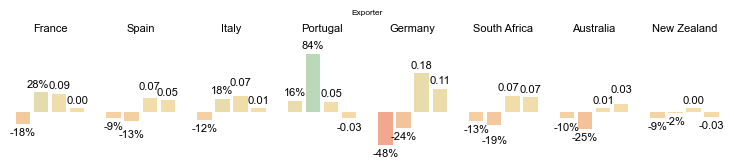

In [315]:
# Comparison panel of wine trade
Wine_diff = dsets["Wine"]["Predictions"]["mean"].sel({"Year": [2016, 2022], "variable": "C"}, drop=True).diff("Year").sel({"Destination": ["GBR", "IRL"]})
Wine_trade_diff = (dsets["Wine"]["Predictions"]["mean"].sel({"Year": [2016, 2022], "variable": "T_pred"}).diff("Year") / dsets["Wine"]["Predictions"]["mean"].sel({"Year": 2016, "variable": "T_pred"}).squeeze().data).sel({"Destination": ["GBR", "IRL"]})

cm = ColorManager(
    cmap={'continuous': True, 'from_values': {0: colors['c_red'], 0.5: colors['c_yellow'], 1: colors['c_lightgreen'], }},
    vmin=-1,
    vmax=+1
)

fig, axs = plt.subplots(ncols=8, figsize=(7.1, 1), sharey=True)
for idx, country in enumerate(["FRA", "ESP", "ITA", "PRT", "DEU", "ZAF", "AUS", "NZL"]):
   
    _T = Wine_trade_diff.sel({"Source": country, "Destination": "GBR"}).data[0]
    if _T < 0.6:
        _rect = axs[idx].bar([0], [_T], color=cm.map_to_color(_T), lw=0)
        _patch = _rect.get_children()[0]
        _x, _y = 0, _patch._height
    else:
        _rect_1 = patches.Polygon([(-0.4, 0), (-0.4, 0.7), (0.4, 0.8), (0.4, 0)], color=cm.map_to_color(_T), lw=0)
        _rect = patches.Polygon([(-0.4, 0.75), (-0.4, 1.5), (0.4, 1.5), (0.4, 0.85)], color=cm.map_to_color(_T), lw=0)
        axs[idx].add_patch(_rect_1)
        axs[idx].add_patch(_rect)
        _x, _y = 0, 1.5

    axs[idx].text(_x, _y + np.sign(_y)*0.05, "{t:.0f}%".format(t=100*_T), ha='center', va='top' if _y < 0 else 'bottom')
    
    _T = Wine_trade_diff.sel({"Source": country, "Destination": "IRL"}).data[0]
    _rect = axs[idx].bar([1], [_T], color=cm.map_to_color(_T), lw=0)
    _patch = _rect.get_children()[0]
    _x, _y = 1, _patch._height
    axs[idx].text(_x, _y + np.sign(_y)*0.05, "{t:.0f}%".format(t=100*_T), ha='center', va='top' if _T < 0 else 'bottom')
            
    _C = Wine_diff.sel({"Destination": "GBR", "Source": country}).squeeze().data
    _rect = axs[idx].bar([2], [np.sign(_C)*max(3*abs(_C), 0.05)], color=cm.map_to_color(_C) if _C > 0 else cm.map_to_color(_C), lw=0)
    _patch = _rect.get_children()[0]
    _x, _y = 2, _patch._height
    axs[idx].text(_x, _y + np.sign(_y)*0.05, "{t:.2f}".format(t=_C), ha='center', va='bottom' if _C > 0 else 'top')

    _C = Wine_diff.sel({"Destination": "IRL", "Source": country}).squeeze().data
    _rect = axs[idx].bar([3], [np.sign(_C)*max(3*abs(_C), 0.05)], color=cm.map_to_color(_C) if _C > 0 else cm.map_to_color(_C), lw=0)
    _patch = _rect.get_children()[0]
    _x, _y = 3, _patch._height
    
    axs[idx].text(_x, _y + np.sign(_y)*0.05, "{t:.2f}".format(t=_C), ha='center', va='bottom' if _C > 0 else 'top')
    axs[idx].set_title(putils.property_from_iso3(country, item='Name', correct=True), y=1.1)

    axs[idx].axis('off')
fig.suptitle('Exporter', y=1.4, fontsize=6)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Manual adjustments to prevent overlap
axs[0].texts[1]._x = 0.8
axs[1].texts[1]._y = -0.25
axs[1].texts[2]._y = 0.3
axs[2].texts[2]._y = 0.35
axs[5].texts[1]._y = -0.34
axs[5].texts[2]._x = 1.8
axs[5].texts[3]._x = 3
axs[6].texts[-1]._y = 0.25

In [316]:
if img_dir:
    fig.savefig("Images/Brexit_wine_comp.pdf", pad_inches=0)

# Gravity model comparison
## Covariate-based comparison

In [414]:
# Standard settings for median, mean, and errorbars
ebar_kws = dict(elinewidth=1, capsize=2, lw=0)
mean_kws = dict(markersize=5, marker='v')
median_kws = dict(marker='D', s=10)

def create_accuracy_panel():
    """ Set up a figure for the accuracy panel """
    fig, axs = plt.subplots(figsize=(page_width, 1.5), ncols=2)
    fig.subplots_adjust(right=0.875, wspace=0.2)
    legend_ax = fig.add_axes([0.86, -0.15, 0.08, 1])
    legend_ax.errorbar(1.05, 0.7, 0.3, color=colors['c_darkgrey'], **ebar_kws, **mean_kws)
    legend_ax.scatter(1.05, 0.5, zorder=2, color=colors['c_darkgrey'], **median_kws)
    legend_ax.set_ylim(0, 1.01)
    legend_ax.set_xlim(0.85, 1.2)
    legend_ax.text(0.8, 1.0, 'Std', ha='left', va='top', transform=legend_ax.transAxes)
    legend_ax.text(0.8, 0.7, 'Mean', ha='left', va='center', transform=legend_ax.transAxes)
    legend_ax.text(0.8, 0.5, 'Median', ha='left', va='center', transform=legend_ax.transAxes)
    legend_ax.plot([1, 1.1], [0.1, 0.1], lw=1, color=colors['c_orange'])
    legend_ax.plot([1, 1.1], [0.2, 0.2], lw=1, color=colors['c_darkblue'])
    legend_ax.text(0.8, 0.2, 'OT', ha='left', va='center', transform=legend_ax.transAxes)
    legend_ax.text(0.8, 0.1, 'Gravity', ha='left', va='center', transform=legend_ax.transAxes)
    legend_ax.axis('off')
    box_ax = fig.add_axes([0.88, -0.16, 0.12, 1.1], zorder=-2)
    box_ax.xaxis.set_visible(False)
    box_ax.yaxis.set_visible(False)
    for s in ['top', 'bottom', 'right', 'left']:
        box_ax.spines[s].set_visible(False)
    rect = patches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96, linewidth=1, edgecolor=colors['c_lightgrey'], alpha=0.8, facecolor='white', transform=box_ax.transAxes, boxstyle='Round, pad=0, rounding_size=0.02')
    box_ax.add_patch(rect)

    # Add a fancy legend
    for col in [0, 1]:
        axs[col].xaxis.set_visible(False)
        for spine in ['top', 'bottom', 'left', 'right']:
            axs[col].spines[spine].set_visible(False)

    return fig, axs

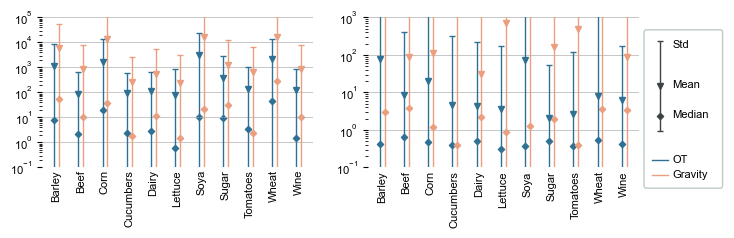

In [423]:
# Accuracy panel
fig, axs = create_accuracy_panel()
for idx, (key, value) in enumerate(dsets.items()):

    # OT estimates
    _OT_est = value['Predictions'].sel({"variable": "T_pred"})['mean']

    # Gravity estimates
    _Gravity_est = value['Gravity_covariates']['predicted']

    # Mean FAO data, averaged over reporter
    _FAO_data = value['FAO_data'].mean('Reporter', skipna=True)

    # Std on FAO data: we use the OT estimated std which matches the std from the reporter-spread but contains no NaNs or zeros
    _FAO_std = value['Predictions'].sel({"variable": "T_pred"})['std'].where(lambda x: x>0)

    # RMSE in units of the uncertainty
    rel_RMSE_OT = np.sqrt((_OT_est - _FAO_data)**2 / _FAO_std**2)
    rel_RMSE_Gravity = np.sqrt((_Gravity_est - _FAO_data)**2 / _FAO_std**2)

    # RMSE
    axs[0].errorbar(
        idx-0.1,
        np.sqrt((_OT_est-_FAO_data)**2).mean(),
        np.sqrt((_OT_est-_FAO_data)**2).std(),
        color=colors['c_darkblue'], **ebar_kws, **mean_kws
    )
    axs[0].errorbar(
        idx+0.1,
        np.sqrt((_Gravity_est-_FAO_data)**2).mean(),
        np.sqrt((_Gravity_est-_FAO_data)**2).std(),
        color=colors['c_orange'], **ebar_kws, **mean_kws
    )

    # Median squared error
    axs[0].scatter(
        idx-0.1,
        np.sqrt((_OT_est-_FAO_data)**2).median(),
        color=colors['c_darkblue'], **median_kws
    )
    axs[0].scatter(
        idx+0.1,
        np.sqrt((_Gravity_est-_FAO_data)**2).median(),
        color=colors['c_orange'], **median_kws
    )

    # RMSE (relative)
    axs[1].errorbar(idx-0.1, rel_RMSE_OT.mean(), rel_RMSE_OT.std(),
                   color=colors['c_darkblue'], **ebar_kws, **mean_kws
    )

    # Median squared error (relative)
    axs[1].scatter(idx-0.1, rel_RMSE_OT.median(), color=colors['c_darkblue'], **median_kws)

    axs[1].errorbar(idx+0.1 , rel_RMSE_Gravity.mean(), rel_RMSE_Gravity.std(),
                   color=colors['c_orange'], **ebar_kws, **mean_kws
    )
    axs[1].scatter(idx+0.1, rel_RMSE_Gravity.median(), color=colors['c_orange'], **median_kws)

    # Add axis labels
    for col in [0, 1]:
        axs[col].text(idx, 0.08, key, ha='center', va='top', rotation=90, bbox=dict(facecolor=colors['c_lightblue'], edgecolor=colors['c_darkgrey'], lw=0., alpha=0., pad=0.5, boxstyle='round'))

axs[0].set_ylim(0.1, 1e5)
axs[0].set_yscale('log')
axs[1].set_ylim(0.1, 1000)
axs[1].set_yscale('log')

In [424]:
if img_dir:
    fig.savefig("Images/Gravity_comparison_covariates.pdf", pad_inches=0.01)

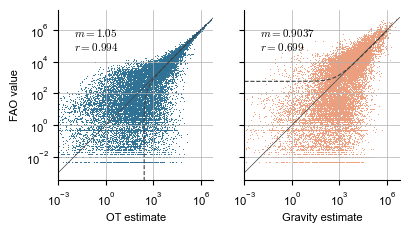

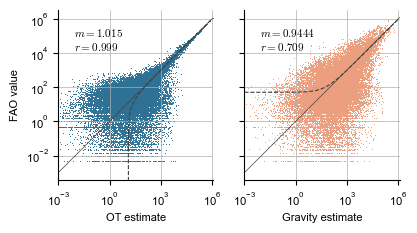

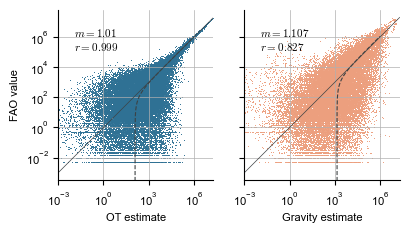

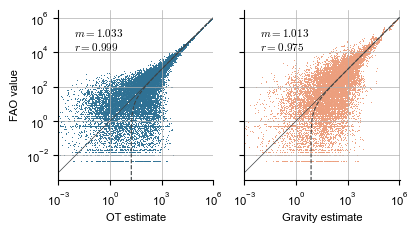

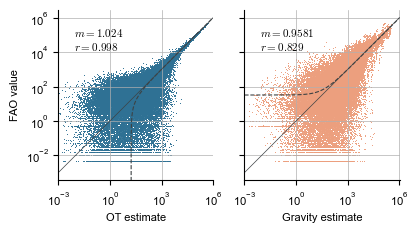

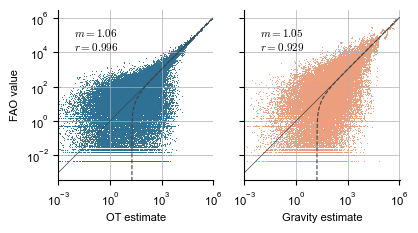

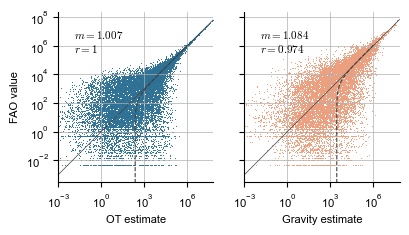

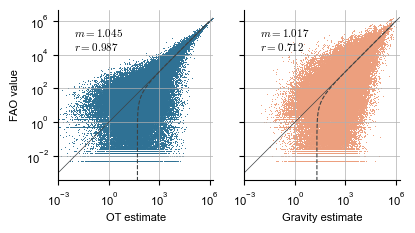

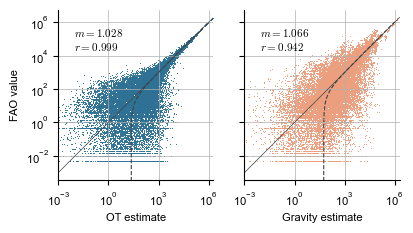

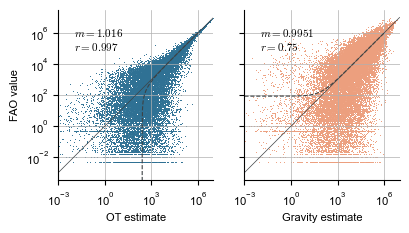

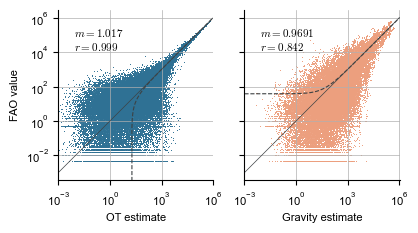

In [408]:
# Plot just OT and gravity
for item in dsets.keys():

    fig, axs = plt.subplots(ncols=2, figsize=(page_width/2, page_width/4), sharey=True, sharex=True)

    # OT estimates
    x_OT, y = dsets[item]['Predictions']['mean'].sel({"variable": "T_pred"}, drop=True).data.flatten(), dsets[item]['FAO_data'].mean("Reporter").data.flatten()
    axs[0].scatter(x_OT, y, color=colors['c_darkblue'], s=0.5, lw=0)

    # Gravity estimates (PPML)
    x_PPML, y_PPML = dsets[item]['Gravity_covariates']['predicted'].data.flatten(), dsets[item]['Gravity_covariates']['FAO_data'].data.flatten()
    axs[1].scatter(x_PPML, y_PPML, color=colors['c_orange'], s=0.5, lw=0)

    # Add linear regressions
    for col, (_x, _y) in enumerate([(x_OT, y), (x_PPML, y_PPML)]):
        mask = ~np.isnan(_x) & ~np.isnan(_y)
        linreg = scipy.stats.linregress(_x[mask], _y[mask])
        axs[col].plot(np.logspace(-3, 6, 1000), linreg.slope*np.logspace(-3, 6, 1000)+linreg.intercept, lw=0.8, color=colors['c_darkgrey'], ls='dashed')
        axs[col].text(0.1, 0.9, rf'$m={linreg.slope:>7.4g}$' + '\n' + fr'$r={linreg.rvalue:7.3g}$' + '\n', transform=axs[col].transAxes, va='top', fontsize=8)
    axs[0].set_xlim(1e-3, None)
    axs[0].set_yscale('log')
    axs[0].set_xscale('log')

    axs[0].set_ylabel("FAO value")
    axs[0].set_xlabel("OT estimate")
    axs[1].set_xlabel("Gravity estimate")

    for col in range(2):
        axs[col].plot([1e-3, axs[0].get_xlim()[1]], [1e-3, axs[0].get_xlim()[1]], lw=0.5, color=colors['c_darkgrey'], ls='solid')
    fig.savefig(f"{img_dir}/SI/{item}.png", pad_inches=0.01)

## Fixed effects

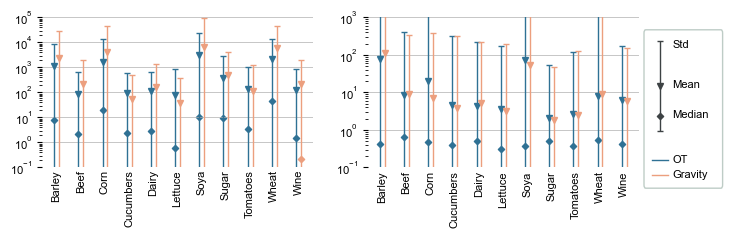

In [426]:
# Accuracy panel
fig, axs = create_accuracy_panel()
for idx, (key, value) in enumerate(dsets.items()):

    # OT estimates
    _OT_est = value['Predictions'].sel({"variable": "T_pred"})['mean']

    # Gravity estimates
    _Gravity_est = value['Gravity_fixed_effects']['predicted']

    # Mean FAO data, averaged over reporter
    _FAO_data = value['FAO_data'].mean('Reporter', skipna=True)

    # Std on FAO data: we use the OT estimated std which matches the std from the reporter-spread but contains no NaNs or zeros
    _FAO_std = value['Predictions'].sel({"variable": "T_pred"})['std'].where(lambda x: x>0)

    # RMSE with std
    axs[0].errorbar(
        idx-0.1,
        np.sqrt((_OT_est-_FAO_data)**2).mean(),
        np.sqrt((_OT_est-_FAO_data)**2).std(),
        color=colors['c_darkblue'], **ebar_kws, **mean_kws
    )
    axs[0].errorbar(
        idx+0.1,
        np.sqrt((_Gravity_est-_FAO_data)**2).mean(),
        np.sqrt((_Gravity_est-_FAO_data)**2).std(),
        color=colors['c_orange'], **ebar_kws, **mean_kws
    )

    # Also show the median
    axs[0].scatter(
        idx-0.1,
        np.sqrt((_OT_est-_FAO_data)**2).median(),
        color=colors['c_darkblue'], **median_kws
    )
    axs[0].scatter(
        idx+0.1,
        np.sqrt((_Gravity_est-_FAO_data)**2).median(),
        color=colors['c_orange'], **median_kws
    )

    # Plot the median residuals in units of the uncertainty
    rel_RMSE_OT = np.sqrt((_OT_est - _FAO_data)**2 / _FAO_std**2)
    axs[1].errorbar(idx-0.1, rel_RMSE_OT.mean(), rel_RMSE_OT.std(),
                   color=colors['c_darkblue'], **ebar_kws, **mean_kws
    )
    axs[1].scatter(idx-0.1, rel_RMSE_OT.median(), color=colors['c_darkblue'], **median_kws)

    rel_RMSE_Gravity = np.sqrt((_Gravity_est - _FAO_data)**2 / _FAO_std**2)
    axs[1].errorbar(idx+0.1 , rel_RMSE_Gravity.mean(), rel_RMSE_Gravity.std(),
                   color=colors['c_orange'], **ebar_kws, **mean_kws
    )
    axs[1].scatter(idx+0.1, rel_RMSE_Gravity.median(), color=colors['c_orange'], **median_kws)

    # Add axis labels
    for col in [0, 1]:
        axs[col].text(idx, 0.08, key, ha='center', va='top', rotation=90, bbox=dict(facecolor=colors['c_lightblue'], edgecolor=colors['c_darkgrey'], lw=0., alpha=0., pad=0.5, boxstyle='round'))

axs[0].set_ylim(0.1, 1e5)
axs[0].set_yscale('log')
axs[1].set_ylim(0.1, 1000)
axs[1].set_yscale('log')

In [427]:
if img_dir:
    fig.savefig("Images/Gravity_comparison_fixed_effects.pdf", pad_inches=0.01)

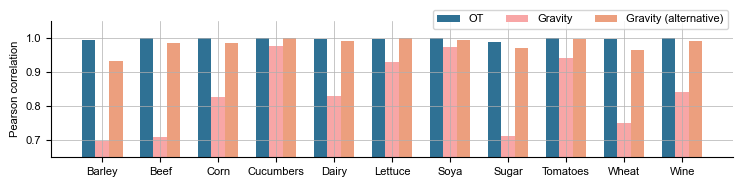

In [482]:
fig, ax = plt.subplots(figsize=(page_width, page_width/5))
# Plot the Pearson R on the data
for idx, (key, value) in enumerate(dsets.items()):

    # OT estimates
    _OT_est = value['Predictions'].sel({"variable": "T_pred"})['mean']

    # Gravity estimates
    _Gravity_est_1 = value['Gravity_covariates']['predicted']
    _Gravity_est_2 = value['Gravity_fixed_effects']['predicted']

    # Mean FAO data, averaged over reporter
    _FAO_data = value['FAO_data'].mean('Reporter', skipna=True)

    ax.bar([3*idx], xr.corr(_OT_est, _FAO_data), color=colors['c_darkblue'], width=0.7, label='OT' if idx == 0 else None)
    ax.bar([3*idx+0.7], xr.corr(_Gravity_est_1, _FAO_data), color=colors['c_pink'], width=0.7, label='Gravity' if idx == 0 else None)
    ax.bar([3*idx+1.4], xr.corr(_Gravity_est_2, _FAO_data), color=colors['c_orange'], width=0.7, label='Gravity (alternative)' if idx == 0 else None)
ax.set(ylim=(0.65, 1.05), ylabel='Pearson correlation')
ax.set_xticks(ticks=[3*idx+0.7 for idx in range(len(dsets))], labels=list(dsets.keys()));
ax.legend(ncols=3, loc='lower right', bbox_to_anchor=(1, 0.9))

In [483]:
if img_dir:
    fig.savefig("Images/Gravity_comparison_corr.pdf", pad_inches=0)

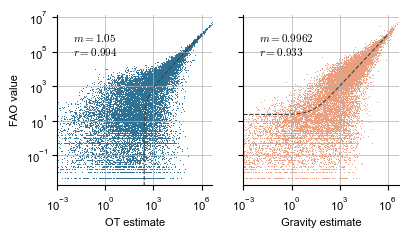

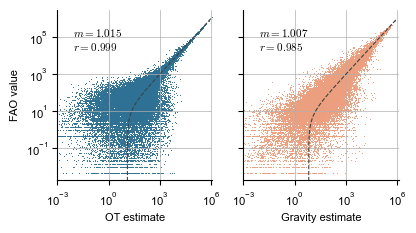

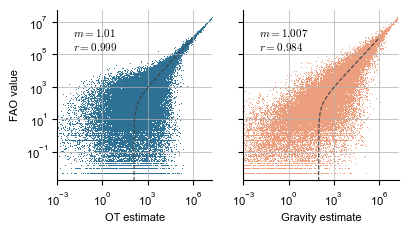

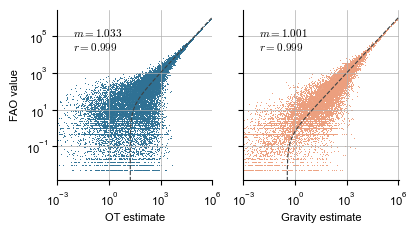

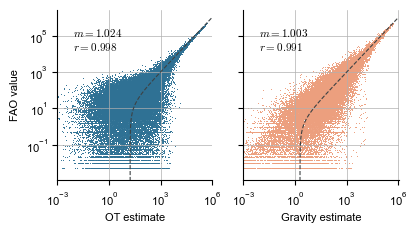

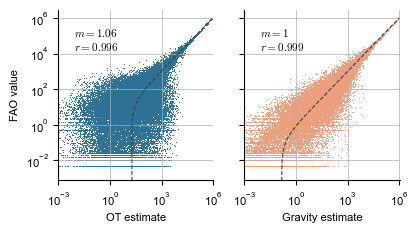

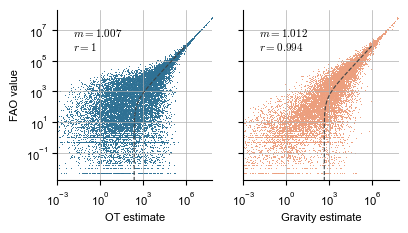

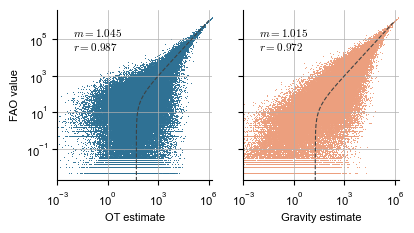

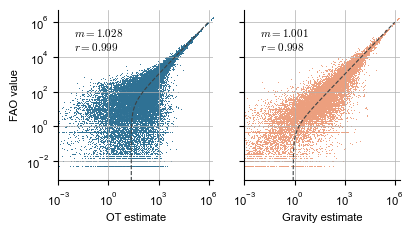

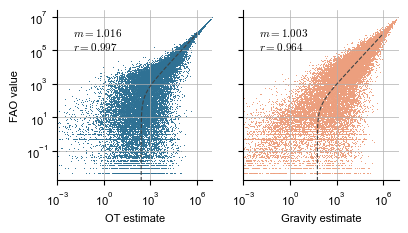

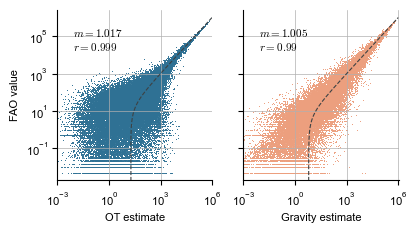

In [347]:
# Plot just OT and gravity
for item in dsets.keys():

    fig, axs = plt.subplots(ncols=2, figsize=(page_width/2, page_width/4), sharey=True, sharex=True)

    # OT estimates
    x_OT, y = dsets[item]['Predictions']['mean'].sel({"variable": "T_pred"}, drop=True).data.flatten(), dsets[item]['FAO_data'].mean("Reporter").data.flatten()
    axs[0].scatter(x_OT, y, color=colors['c_darkblue'], s=0.5, lw=0)

    # Gravity estimates (PPML)
    x_PPML, y_PPML = dsets[item]['Gravity_fixed_effects']['predicted'].data.flatten(), dsets[item]['Gravity_fixed_effects']['FAO_data'].data.flatten()
    axs[1].scatter(x_PPML, y_PPML, color=colors['c_orange'], s=0.5, lw=0)

    # Add linear regressions
    for col, (_x, _y) in enumerate([(x_OT, y), (x_PPML, y_PPML)]):
        mask = ~np.isnan(_x) & ~np.isnan(_y)
        linreg = scipy.stats.linregress(_x[mask], _y[mask])
        axs[col].plot(np.logspace(-3, 6, 1000), linreg.slope*np.logspace(-3, 6, 1000)+linreg.intercept, lw=0.8, color=colors['c_darkgrey'], ls='dashed')
        axs[col].text(0.1, 0.9, rf'$m={linreg.slope:>7.4g}$' + '\n' + fr'$r={linreg.rvalue:7.3g}$' + '\n', transform=axs[col].transAxes, va='top', fontsize=8)
    axs[0].set_xlim(1e-3, None)
    axs[0].set_yscale('log')
    axs[0].set_xscale('log')

    axs[0].set_ylabel("FAO value")
    axs[0].set_xlabel("OT estimate")
    axs[1].set_xlabel("Gravity estimate")

    # for col in range(2):
    #     axs[col].plot([1e-3, axs[0].get_xlim()[1]], [1e-3, axs[0].get_xlim()[1]], lw=0.5, color=colors['c_darkgrey'], ls='solid')
    # fig.savefig(f"{img_dir}/SI/{item}.png", pad_inches=0.01)

In [37]:
for comm in sorted(os.listdir("data")):
    if not os.path.isdir(f"data/{comm}"):
        continue
    if not "trained_models" in os.listdir(f"data/{comm}"):
        continue
    params = pd.read_csv(f"data/{comm}/gravity_estimates/covariates_parameters.csv", index_col=1).drop('Unnamed: 0', axis=1).T[['log_total_output', 'log_total_consumption', 'log_dist', 'cntg', 'cnly', 'lang', 'rta', 'log_rem_importer', 'trf']]
    coeff = params.iloc[0].values
    se = params.iloc[1].values
    name = comm
    if name == 'Dairy':
        name = r'Dairy products$^\star$'
    elif name == 'Sugar':
        name = r'Sugar products$^\dagger$'
    print(f'{name} & '+' & '.join([f'{coeff[i]:>.2g} ({se[i]:>.2g})' for i in range(len(coeff))]) + ' \\\\')

Barley & 0.61 (0.071) & 0.085 (0.017) & -0.43 (0.017) & 1.2 (0.093) & -0.44 (0.12) & 0.72 (0.084) & 1.3 (0.1) & 0.66 (0.056) & -0.0058 (0.023) \\
Beef & 0.34 (0.041) & 0.18 (0.015) & -0.19 (0.017) & 1.7 (0.057) & -0.29 (0.068) & 0.78 (0.079) & 1.5 (0.068) & 0.55 (0.035) & 0.046 (0.017) \\
Corn & 0.86 (0.042) & 0.11 (0.012) & -0.49 (0.018) & 1.6 (0.077) & -0.67 (0.13) & 0.44 (0.081) & 1.4 (0.064) & 0.72 (0.059) & -0.0058 (0.023) \\
Cucumbers & 0.24 (0.047) & 0.27 (0.024) & -0.57 (0.023) & 1.8 (0.086) & -0.68 (0.1) & 1.6 (0.082) & 3.4 (0.21) & 0.46 (0.047) & 0.003 (0.012) \\
Dairy products$^\star$ & 0.58 (0.064) & 0.15 (0.0089) & -0.19 (0.0099) & 1.5 (0.055) & -0.11 (0.056) & 0.79 (0.042) & 1.9 (0.044) & 0.38 (0.026) & -0.066 (0.015) \\
Lettuce & 0.37 (0.044) & 0.13 (0.015) & -0.34 (0.014) & 1.9 (0.064) & -0.3 (0.085) & 0.7 (0.059) & 2.7 (0.12) & 0.31 (0.039) & -0.029 (0.014) \\
Soya & 0.81 (0.073) & 0.21 (0.019) & -0.069 (0.023) & 1.8 (0.13) & -0.84 (0.13) & 1.1 (0.16) & 1.2 (0.091) & 0

In [48]:
params = {}
for comm in sorted(os.listdir("data")):
    if not os.path.isdir(f"data/{comm}"):
        continue
    if not "trained_models" in os.listdir(f"data/{comm}"):
        continue
    params[comm] = pd.read_csv(f"data/{comm}/gravity_estimates/covariates_parameters.csv", index_col=1).drop('Unnamed: 0', axis=1).T[['log_total_output', 'log_total_consumption', 'log_dist', 'cntg', 'cnly', 'lang', 'rta', 'log_rem_importer', 'trf']].T

In [49]:
df_stacked = pd.concat(params, axis=1)

# Optional: sort column levels for clarity
df_stacked = df_stacked.sort_index(axis=1)

In [54]:
df_stacked.to_csv("/Users/thomasgaskin/test.csv")